# 06 — Evaluation, error analysis, and comparison write-up

This notebook doesn't retrain anything — it loads the cross-validated results notebooks 03, 04 and 05
already saved to `data/processed/`, puts the three detectors side by side, and does the part that's easy
to skip but is usually the most informative: looking at *specific* images where each model succeeded or
failed, not just the aggregate numbers.

The three detectors: the from-scratch **sliding-window CNN** (notebook 03), **YOLO on the whole scene
shrunk to 640×640** (notebook 04), and **YOLO on native-resolution tiles** (notebook 05).

In [1]:
import ast
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

from src.models.patch_classifier import PatchClassifier
from src.models.sliding_window import detect

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
plt.rcParams["figure.dpi"] = 110

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)

sw_results = pd.read_csv(PROCESSED_DIR / "sliding_window_cv_results.csv")
yolo_results = pd.read_csv(PROCESSED_DIR / "yolo_cv_results.csv")
sw_sweep_df = pd.read_csv(PROCESSED_DIR / "sliding_window_threshold_sweep.csv")
yolo_sweep_df = pd.read_csv(PROCESSED_DIR / "yolo_threshold_sweep.csv")
SW_THRESHOLD = float(sw_sweep_df.loc[sw_sweep_df["f1"].idxmax(), "threshold"])
YOLO_THRESHOLD = (
    float(yolo_sweep_df.loc[yolo_sweep_df["f1"].idxmax(), "threshold"]) if yolo_sweep_df["f1"].max() > 0 else 0.1
)

sw_results["scene_id"] = sw_results["scene_id"].astype(str)
yolo_results["scene_id"] = yolo_results["scene_id"].astype(str)
print(f"Sliding-window threshold: {SW_THRESHOLD}, YOLO threshold: {YOLO_THRESHOLD}")


Sliding-window threshold: 0.6, YOLO threshold: 0.1


## Side-by-side comparison

All three models were cross-validated on the exact same 19 scenes and 5 folds, and scored with the exact same
`match_detections` / `precision_recall` functions (IoU >= 0.3) — so this comparison is apples-to-apples,
not different papers' self-reported numbers.

How each operating threshold was chosen matters for reading the table: the sliding-window threshold was tuned on
fold 0's held-out scenes; the whole-scene YOLO used an untuned fallback (`conf=0.1`, its sweep found nothing); the
tiled YOLO's threshold is chosen *leave-one-fold-out* (on the other four folds, never the scored one), the most
conservative protocol of the three.

In [2]:
def summarize(df: pd.DataFrame, name: str) -> dict:
    tp, fp, fn = df["tp"].sum(), df["fp"].sum(), df["fn"].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {"model": name, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall,
            "scenes_with_a_hit": int((df["tp"] > 0).sum())}


tiled_single = pd.read_csv(PROCESSED_DIR / "tiled_cv_results_single_scale.csv")
tiled_multi = pd.read_csv(PROCESSED_DIR / "tiled_cv_results_multi_scale.csv")
tiled_hitk = pd.read_csv(PROCESSED_DIR / "tiled_hit_at_k.csv")
for df in (tiled_single, tiled_multi):
    df["scene_id"] = df["scene_id"].astype(str)

summary = pd.DataFrame([
    summarize(sw_results, "Sliding-window CNN (from scratch)"),
    summarize(yolo_results, "YOLO11n, whole scene at 640px"),
    summarize(tiled_single, "YOLO11n, native-resolution tiles"),
    summarize(tiled_multi, "YOLO11n, native tiles, multi-scale"),
])
summary

,model,tp,fp,fn,precision,recall,scenes_with_a_hit
0,Sliding-window CNN (from scratch),8,4203,13,0.001900,0.380952,8
1,"YOLO11n, whole scene at 640px",2,22,19,0.083333,0.095238,2
2,"YOLO11n, native-resolution tiles",6,0,15,1.000000,0.285714,6
3,"YOLO11n, native tiles, multi-scale",7,14,14,0.333333,0.333333,7


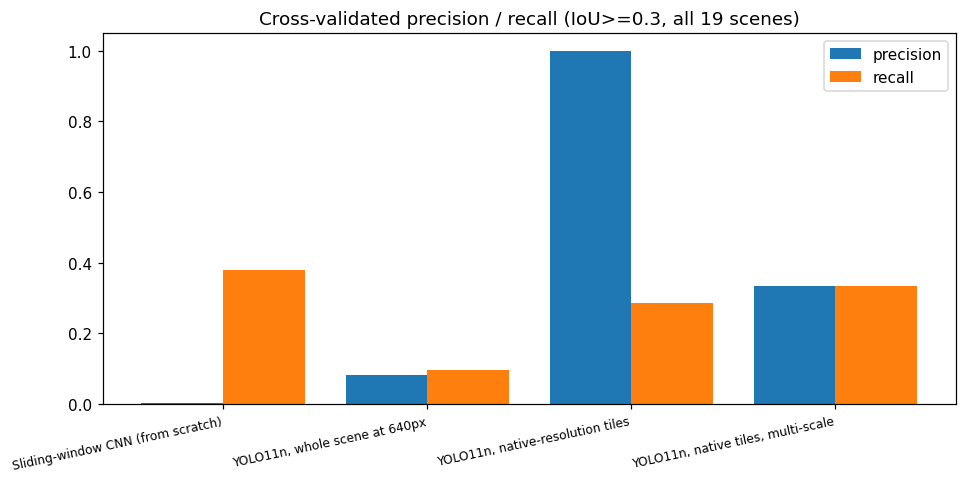

Tiled YOLO, threshold-free: in how many of the 18 scenes with a Waldo is he among the top-k boxes?


scanning,multi-scale,single-scale
k,,
1,10,8
3,13,10
5,13,10
10,14,10
20,14,10


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["precision"], width=0.4, label="precision")
ax.bar([i + 0.2 for i in x], summary["recall"], width=0.4, label="recall")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["model"], rotation=12, ha="right", fontsize=8)
ax.legend()
ax.set_title("Cross-validated precision / recall (IoU>=0.3, all 19 scenes)")
plt.tight_layout()
plt.show()

print("Tiled YOLO, threshold-free: in how many of the 18 scenes with a Waldo is he among the top-k boxes?")
tiled_hitk.pivot(index="k", columns="scanning", values="scenes_hit")

## Per-scene breakdown

Where specifically does each model succeed or fail? This is what points us at *which* images to look at
next, rather than staring at aggregate numbers.

In [4]:
merged = sw_results.merge(yolo_results, on="scene_id", suffixes=("_sw", "_yolo"))[
    ["scene_id", "tp_sw", "fp_sw", "fn_sw", "tp_yolo", "fp_yolo", "fn_yolo"]
]
merged = merged.merge(
    tiled_multi[["scene_id", "tp", "fp", "fn"]].rename(columns={"tp": "tp_tiled", "fp": "fp_tiled", "fn": "fn_tiled"}),
    on="scene_id",
)
merged

,scene_id,tp_sw,fp_sw,fn_sw,tp_yolo,fp_yolo,fn_yolo,tp_tiled,fp_tiled,fn_tiled
0,1,1,357,0,0,0,1,0,0,1
1,2,0,286,1,0,1,1,0,0,1
2,6,1,204,0,0,1,1,1,0,0
3,12,1,303,0,0,7,1,0,0,1
4,4,0,135,1,0,0,1,0,0,1
5,9,1,378,0,0,1,1,0,0,1
6,14,0,104,1,0,0,1,0,0,1
7,17,1,208,1,1,4,1,1,0,1
8,3,0,104,1,0,0,1,0,0,1
9,10,1,70,1,1,1,1,1,1,1


## Visual error analysis (sliding-window CNN and whole-scene YOLO)

Load the two whole-scene models and look directly at a few informative scenes: one where a model gets a hit, one
that both miss, and the sliding-window model's typical failure mode (swamped by false positives). The tiled
detector's held-out pictures are in notebook 05.

**Read these pictures with one caution.** They use the *saved* models, each trained on 15 of the 19 scenes,
so a detection on a scene the model trained on is memorization, not held-out evidence. The cross-validated
table above (where every scene is scored by a model that never saw it) is the honest measure; the pictures
are for understanding what the boxes look like.

In [5]:
sw_model = PatchClassifier()
sw_model.load_state_dict(torch.load(MODELS_DIR / "sliding_window_classifier.pt", map_location="cpu"))
sw_model.eval()

yolo_model = YOLO(str(MODELS_DIR / "yolo_detector.pt"))


def show_both(scene_id: str, sw_threshold: float = SW_THRESHOLD, yolo_conf: float = YOLO_THRESHOLD, max_sw_boxes: int = 30):
    scene = scenes[scenes["scene_id"] == scene_id].iloc[0]
    image = Image.open(scene["image_path"])

    sw_dets = detect(sw_model, image, score_threshold=sw_threshold, nms_iou_threshold=0.2)
    yolo_result = yolo_model.predict(image, conf=yolo_conf, verbose=False)[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, title in zip(axes, ["Sliding-window CNN", "YOLO11n"]):
        ax.imshow(image)
        for (x1, y1, x2, y2) in scene["boxes"]:
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
        ax.set_title(f"{title} — scene {scene_id}", fontsize=10)
        ax.axis("off")

    for det in sorted(sw_dets, key=lambda d: d.score, reverse=True)[:max_sw_boxes]:
        x1, y1, x2, y2 = det.box
        axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1, alpha=0.6))
    if len(sw_dets) > max_sw_boxes:
        axes[0].set_title(axes[0].get_title() + f" ({len(sw_dets)} raw detections, showing top {max_sw_boxes})", fontsize=8)

    for box in yolo_result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        axes[1].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        axes[1].text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)
    if len(yolo_result.boxes) == 0:
        axes[1].set_title(axes[1].get_title() + " (no detections)", fontsize=8)

    plt.tight_layout()
    plt.show()

### Case 1: does either model ever get a true positive?

YOLO scenes with a true positive: ['17', '10']
Sliding-window scenes with a true positive: ['1', '6', '12', '9', '17', '10', '16', '8']


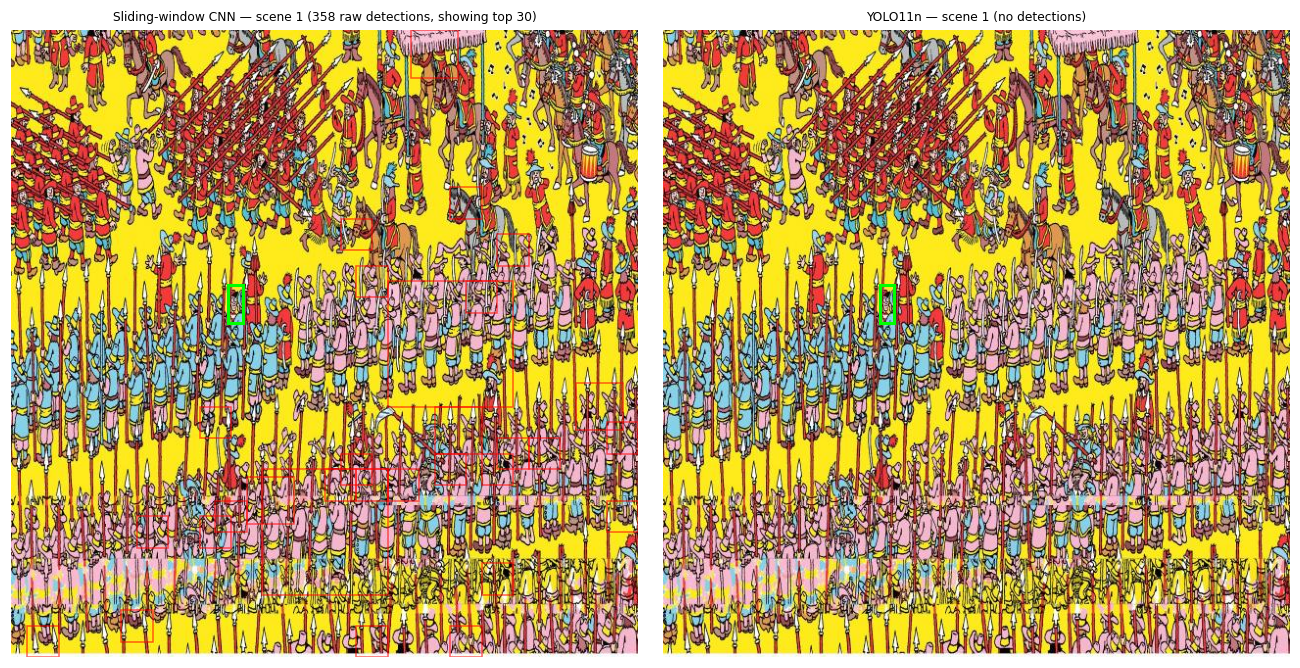

In [6]:
yolo_success_scenes = yolo_results[yolo_results["tp"] > 0]["scene_id"].tolist()
sw_success_scenes = sw_results[sw_results["tp"] > 0]["scene_id"].tolist()
print(f"YOLO scenes with a true positive: {yolo_success_scenes}")
print(f"Sliding-window scenes with a true positive: {sw_success_scenes}")

if sw_success_scenes:
    show_both(sw_success_scenes[0])
elif yolo_success_scenes:
    show_both(yolo_success_scenes[0])
else:
    print("Neither model produced a single true positive across all 19 cross-validated scenes.")
    print("Showing one scene anyway, to look at what each model predicts instead of a true match.")
    show_both(scenes["scene_id"].iloc[0])

### Case 2: a scene both models miss

Scenes both models fully miss: ['2', '4', '14', '3', '18', '5', '13', '19', '7', '15']


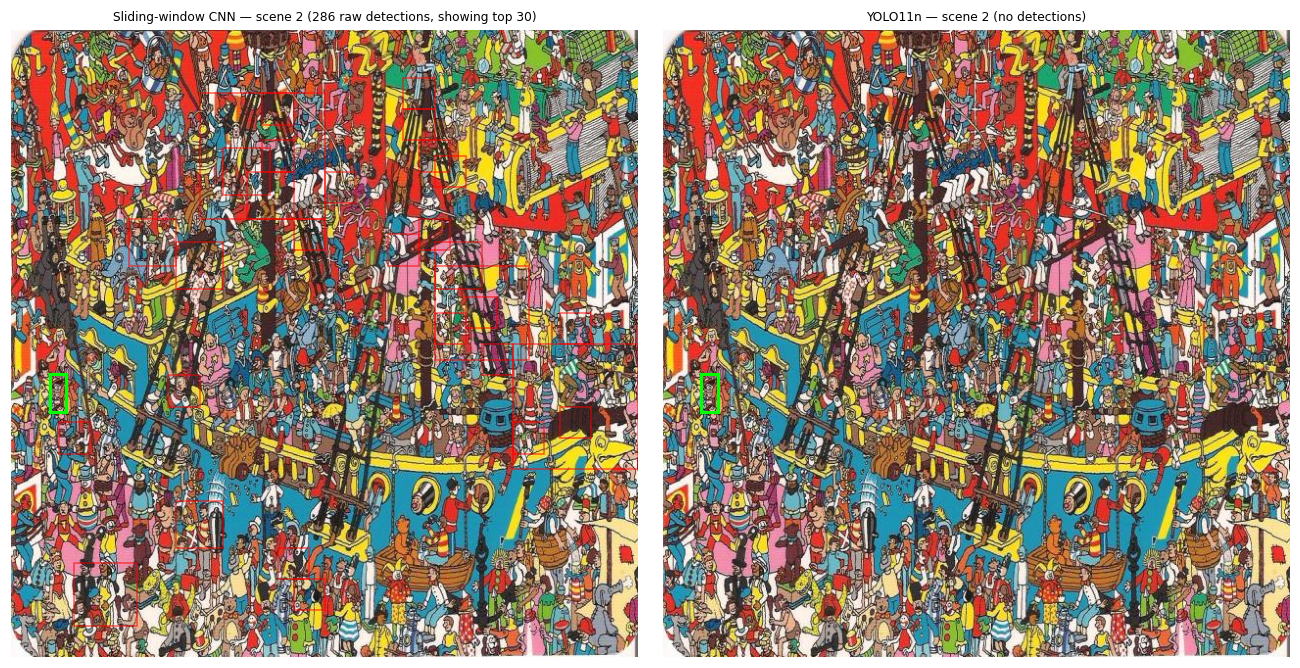

In [7]:
both_miss = merged[(merged["tp_sw"] == 0) & (merged["tp_yolo"] == 0) & (merged["fn_sw"] > 0)]["scene_id"].tolist()
print(f"Scenes both models fully miss: {both_miss}")
if both_miss:
    show_both(both_miss[0])

### Case 3: the sliding-window model's typical false-positive flood

Scene with the most sliding-window false positives: 19


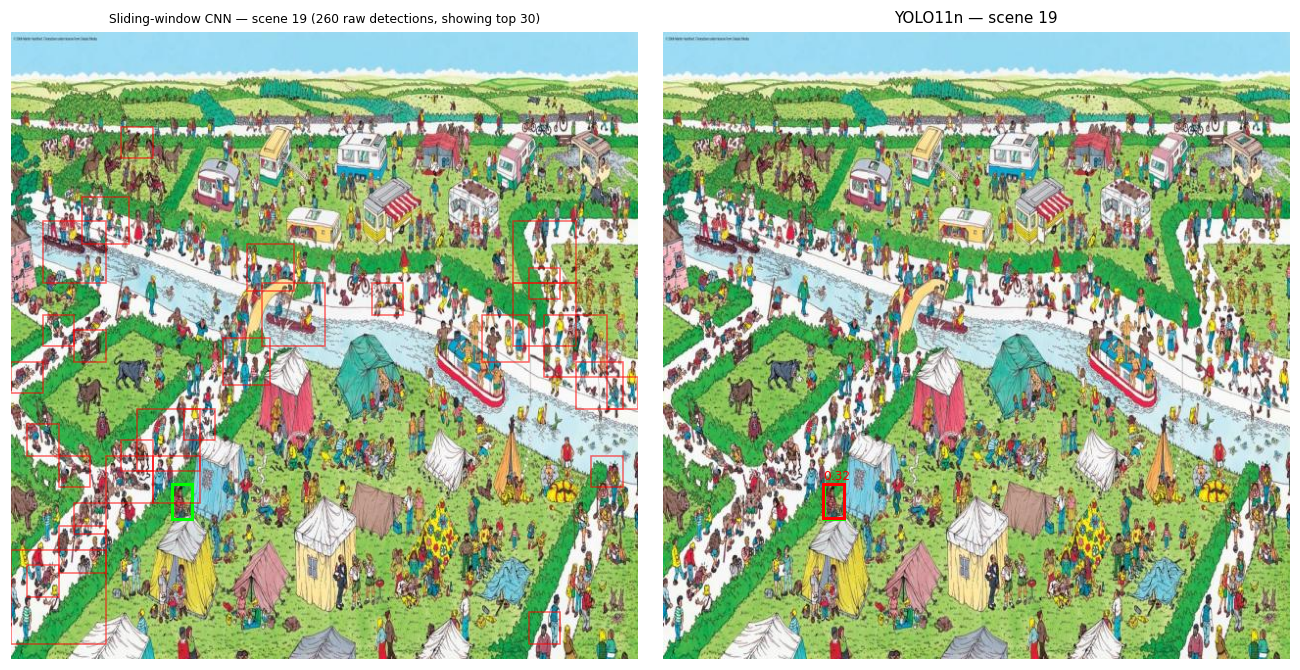

In [8]:
worst_fp_scene = sw_results.loc[sw_results["fp"].idxmax(), "scene_id"]
print(f"Scene with the most sliding-window false positives: {worst_fp_scene}")
show_both(worst_fp_scene)

## Practical comparison: size and speed

In [9]:
sw_params = sum(p.numel() for p in sw_model.parameters())
yolo_params = sum(p.numel() for p in yolo_model.model.parameters())

practical = pd.DataFrame([
    {"model": "Sliding-window CNN", "parameters": sw_params, "inference": "thousands of batched forward passes/image"},
    {"model": "YOLO11n", "parameters": yolo_params, "inference": "single forward pass/image"},
])
practical

,model,parameters,inference
0,Sliding-window CNN,98049,thousands of batched forward passes/image
1,YOLO11n,2590035,single forward pass/image


## Write-up: methodology, results, failure cases, what was learned

**Methodology.** Three detectors were trained and cross-validated on the same 19 hand-verified "hidden in a
crowd" scenes (notebook 01 filtered these out of a 65-image source dataset that turned out to be mostly
unrelated portrait closeups), using the same scene-level 5-fold split (notebook 02) and the same
IoU-matched (≥ 0.3) precision/recall/localization-error metrics (`src/eval/metrics.py`) — never accuracy, and
never a framework's self-reported metric for one model without computing it for the others. Training data was
expanded beyond the raw scenes (notebook 02, Part 2): ~3,100 Hey-Waldo patches for the sliding-window
classifier, and copy-paste synthetic images for YOLO. Evaluation is always on real, unmodified held-out scenes,
and synthetic data only ever comes from a fold's *training* scenes.

**Results** (the table above is computed live from the saved cross-validation results):

| | found | false positives | missed | precision | recall | scenes with a hit |
|---|---|---|---|---|---|---|
| Sliding-window CNN | 8 | 4,203 | 13 | 0.002 | 0.38 | 8 / 19 |
| YOLO11n, whole scene at 640 px | 2 | 22 | 19 | 0.083 | 0.095 | 2 / 19 |
| YOLO11n, native tiles (single-scale) | 6 | 0 | 15 | 1.00 | 0.29 | 6 / 19 |
| YOLO11n, native tiles, multi-scale | 7 | 14 | 14 | 0.33 | 0.33 | 7 / 19 |

Threshold-free (notebook 05): with multi-scale tiled scanning, Waldo is the detector's single most confident box
in **10 of the 18 scenes that contain him, in its top 3 in 13, and in its top 10 in 14** (single-scale: 8 / 10 /
10). That is the metric closest to how the demo is used, and it is the first result in this project that finds
Waldo more often than not.

The ranking of the detectors is clear at the top and bottom, less so in between. **Native-resolution tiling is
the main win**: running YOLO on tiles instead of a scene shrunk to 640×640 took it from 2 hits (22 false alarms)
to 6–7 hits, and the sliding-window CNN, which finds Waldo more often than whole-scene YOLO (8 vs 2), does so by
firing ~220 times per scene (precision 0.002). Multi-scale scanning ranks Waldo better than single-scale but does
not score better on precision/recall with a held-out threshold — that threshold is unstable with so few positives.

**A data bug that mattered.** Roboflow's export had flipped or rotated 8 of the 19 pages relative to the
Hey-Waldo scans, and an early version of this project mapped Roboflow's boxes onto the scans by rescaling only.
For those scenes the "ground truth" landed on a policeman, a letter, a red panel. The tiled YOLO trained and
scored on those boxes found Waldo in its top-10 for 4 of 18 scenes; the identical recipe on correctly aligned
boxes: 10 of 18. Notebook 02 now detects each scene's orientation by image correlation (≈ 0.99 for the right one,
≤ 0.75 for every wrong one), refuses to continue without a clear match, and shows every box; the box math has
unit tests for all 8 flips/rotations. The sliding-window and whole-scene YOLO measurements were never affected
(they use Roboflow's images with Roboflow's own boxes); only the synthetic crops in notebook 04 were, and that
notebook was retrained.

**Caveats that matter.** (1) There are only 21 Waldo boxes in 18 scenes, so every number here has wide error
bars; rerunning the whole-scene YOLO after fixing its crop pool changed its result from 4 hits to 2 — a mix of the
corrected crops and plain retraining noise that I cannot separate. (2) Operating thresholds are not equally rigorous: the sliding-window one was tuned on
fold 0 only, the whole-scene YOLO used an untuned fallback (`conf=0.1`), and the tiled YOLO's is chosen
leave-one-fold-out. (3) The multi-scale variant was chosen from four on these same scenes, so its numbers are
somewhat optimistic. (4) Three annotated "Waldos" are portraits on postcard stamps, not hidden figures.
(5) The saved sliding-window and whole-scene models are single fold models trained on 15 of the 19 scenes, and
the tiled demo model is trained on all 19 — which means it cannot be scored on anything held out.

**Failure modes.**
- *Sliding-window CNN*: over-fires. Scores for Waldo windows and background windows overlap almost
  completely (no threshold gives a usable trade-off), and the classifier's training crops (clean,
  centered) look nothing like the arbitrary crops a sliding window produces — a likely cause, not a tested
  one. Hard-negative mining (225 mined negatives) changed nothing (fold 0: precision 0.003 → 0.002,
  recall 0.75 → 0.75).
- *Whole-scene YOLO11n*: Waldo is ~18×35 px after the 640×640 shrink (median), and in every fold the
  validation box loss is well above the training box loss (about 1.8× to 4.8×) — it under-generalizes.
- *Tiled YOLO11n*: no box matching Waldo appears at confidence ≥ 0.01 in scenes 2, 3 and 13, and in scene 7 the
  first one is at rank 36; I have not analysed why. Its confidence also does not look consistent across folds
  (the best threshold ranged from 0.3 to 0.7), which is what makes a single threshold unreliable.

**Speed** (this laptop CPU, per full scene): sliding-window CNN ≈ 4.3 s; whole-scene YOLO ≈ 0.12 s; tiled YOLO
≈ 1.8 s single-scale, ≈ 6 s with three scales.

**What was learned** (mapped to the project's learning objectives):
- *IoU, NMS, sliding windows*: implemented from scratch (`src/eval/box_utils.py`,
  `src/models/sliding_window.py`), not imported from a detection framework — and reused to merge tile
  detections in notebook 05.
- *Why detection metrics differ from accuracy*: with ~1 positive window per ~2,300 (notebook 01), a
  detector can look fine under accuracy while being useless — the sliding-window model's 0.002 precision is
  exactly that case.
- *Scene-level splitting*: checked explicitly on the raw split (notebook 01) and on our k-fold assignment
  (notebook 02), and respected when generating synthetic data (only from a fold's training scenes).
- *Sliding window vs YOLO*: built on the same data and evaluation code, so the comparison is controlled — they
  fail differently (many false alarms vs many misses), and YOLO is far faster per image.
- *Small objects in a low-data regime*: input resolution mattered more than any modelling trick — the
  largest single improvement came from not shrinking the scene — and 19 scenes remain very little.
- *Verify data on every example, not a sample*: a four-image spot check missed a label bug that affected 8 of 19
  scenes and quietly capped every result built on it.

**What would be worth trying next** (hypotheses, none tested here): more real, correctly-boxed scenes remain
the most direct lever (each fold trains on only ~15 distinct Waldos). Averaging several seeds or a larger YOLO
variant would reduce the run-to-run variance seen above. Examining why scenes 2, 3, 13 and 7 fail (size,
art style, occlusion?) would show whether the misses are data or model problems. And a calibrated confidence
(e.g. one threshold fit across all folds' out-of-fold detections) would make a fixed cut-off usable.